# Box Office Analysis

* This notebook contains an analysis of top box office hits in the 21st century
* We will extract the Oscar winners and nominees from each year's list of the top 200 highest grossing films, and we'll build an understanding of the relationship between diverse critical acclaim and financial success

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
box_office = pd.read_csv("../data/box_office.csv")

In [4]:
box_office.head(5)

,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America"
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America


**Research Question:** Did #OscarsSoWhite (2015-2016) produce measurable changes in Oscar nomination diversity, and did films with diverse leads perform differently at the box office?

**Pivot year:** Ceremony 88 (2016) = OscarsSoWhite controversy. Post-reform = **Ceremony >= 89** (2017 onward).

In [5]:
# -- 0. Setup & Imports -------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import re, os, warnings
warnings.filterwarnings('ignore')

# Paths -- notebook lives in data_analysis/, data is one level up
DATA_DIR = '../data/'
OUT_DIR  = '../data_story_outputs/'
os.makedirs(OUT_DIR, exist_ok=True)

# Color palette
C = {
    'pre'  : '#8B9DC3',  # muted blue  -- pre-2016
    'post' : '#E8A838',  # amber       -- post-2016
    'poc'  : '#E53E3E',  # red         -- POC lead
    'white': '#CBD5E0',  # light grey  -- white lead
    'dark' : '#2D3748',
}
plt.rcParams.update({
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 12,
    'axes.labelsize'   : 10,
})

print('Setup complete.')
print('DATA_DIR :', os.path.abspath(DATA_DIR))
print('OUT_DIR  :', os.path.abspath(OUT_DIR))


Setup complete.
DATA_DIR : /Commjhub/jupyterhub/home/fiherzog/comm3180_S26_Data_Project/data
OUT_DIR  : /Commjhub/jupyterhub/home/fiherzog/comm3180_S26_Data_Project/data_story_outputs


In [6]:
# -- 1a. Oscar nominations (tab-separated) ------------------------------
oscars = pd.read_csv(DATA_DIR + 'oscars.csv', sep='\t', encoding='utf-8')

# Known structure: Ceremony, Year, Category, CanonicalCategory, Film, Name, Winner, FilmId
oscars['Winner']    = oscars['Winner'].fillna(False).astype(bool)
oscars['post_2016'] = oscars['Ceremony'] >= 89  # Ceremony 89 = 2017 awards show

print(f'Shape       : {oscars.shape}')
print(f'Ceremonies  : {oscars["Ceremony"].min()} - {oscars["Ceremony"].max()}')
print('\nAll columns :', oscars.columns.tolist())
print('\nCanonicalCategory sample:', oscars['CanonicalCategory'].unique()[:8].tolist())
oscars.head(3)


Shape       : (12118, 15)
Ceremonies  : 1 - 98

All columns : ['Ceremony', 'Year', 'Class', 'CanonicalCategory', 'Category', 'Film', 'FilmId', 'Name', 'Nominees', 'NomineeIds', 'Winner', 'Detail', 'Note', 'Citation', 'post_2016']

CanonicalCategory sample: ['ACTOR IN A LEADING ROLE', 'ACTRESS IN A LEADING ROLE', 'ART DIRECTION', 'CINEMATOGRAPHY', 'DIRECTING (Comedy Picture)', 'DIRECTING (Dramatic Picture)', 'VISUAL EFFECTS', 'BEST PICTURE']


,Ceremony,Year,Class,CanonicalCategory,Category,Film,FilmId,Name,Nominees,NomineeIds,Winner,Detail,Note,Citation,post_2016
0,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,The Noose|The Patent Leather Kid,tt0019217|tt0018253,Richard Barthelmess,Richard Barthelmess,nm0001932,False,Nickie Elkins|The Patent Leather Kid,NaN,NaN,False
1,1,1927/28,Acting,ACTOR IN A LEADING ROLE,ACTOR,The Last Command|The Way of All Flesh,tt0019071|tt0019553,Emil Jannings,Emil Jannings,nm0417837,True,General Dolgorucki [Grand Duke Sergius Alexand...,NaN,NaN,False
2,1,1927/28,Acting,ACTRESS IN A LEADING ROLE,ACTRESS,A Ship Comes In,tt0018389,Louise Dresser,Louise Dresser,nm0237571,False,Mrs. Pleznik,NaN,NaN,False


In [7]:
# -- 1b. Box office data -- COLUMN DISCOVERY ----------------------------
# After this runs, copy the column names into the Column Map (Section 2)
boxoffice = pd.read_csv(DATA_DIR + 'enhanced_box_office_data(2000-2024)u.csv')

print(f'Shape: {boxoffice.shape}')
print('\n*** ALL COLUMNS -- copy into Column Map below ***')
for i, col in enumerate(boxoffice.columns):
    print(f'  [{i:02d}] {repr(col)}')
print('\nFirst 3 rows:')
boxoffice.head(3)


Shape: (5000, 13)

*** ALL COLUMNS -- copy into Column Map below ***
  [00] 'Rank'
  [01] 'Release Group'
  [02] '$Worldwide'
  [03] '$Domestic'
  [04] 'Domestic %'
  [05] '$Foreign'
  [06] 'Foreign %'
  [07] 'Year'
  [08] 'Genres'
  [09] 'Rating'
  [10] 'Vote_Count'
  [11] 'Original_Language'
  [12] 'Production_Countries'

First 3 rows:


,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America"
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America


In [8]:
# -- 1c. Comprehensive demographics -- COLUMN DISCOVERY -----------------
demo_comp = pd.read_csv(DATA_DIR + 'oscars_demographics_comprehensive_2.csv')

print(f'Shape: {demo_comp.shape}')
print('\n*** ALL COLUMNS -- copy into Column Map below ***')
for i, col in enumerate(demo_comp.columns):
    print(f'  [{i:02d}] {repr(col)}')
print('\nFirst 3 rows:')
demo_comp.head(3)


Shape: (11176, 9)

*** ALL COLUMNS -- copy into Column Map below ***
  [00] 'year_film'
  [01] 'year_ceremony'
  [02] 'ceremony'
  [03] 'Category'
  [04] 'gender'
  [05] 'name'
  [06] 'Race'
  [07] 'film'
  [08] 'winner'

First 3 rows:


,year_film,year_ceremony,ceremony,Category,gender,name,Race,film,winner
0,1927,1928,1,Best Actor,Male,Emil Jannings,White,The Last Command,True
1,1927,1928,1,Best Actress,Female,Janet Gaynor,White,7th Heaven,True
2,1928,1929,2,Best Actor,Male,Warner Baxter,White,In Old Arizona,True


In [9]:
# -- 1d. Religion/orientation dataset (1927-2014, loads cleanly) --------
demo_hist = pd.read_csv(DATA_DIR + 'oscars_religion_orientation.csv')

demo_hist['race']   = demo_hist['race_ethnicity_gold'].fillna(demo_hist['race_ethnicity'])
demo_hist['year']   = pd.to_numeric(demo_hist['year_of_award'], errors='coerce')
demo_hist           = demo_hist.dropna(subset=['year'])
demo_hist['year']   = demo_hist['year'].astype(int)
demo_hist['decade'] = (demo_hist['year'] // 10) * 10
demo_hist['is_poc'] = ~demo_hist['race'].str.contains('White', na=True)

print(f'Shape : {demo_hist.shape}')
print(f'Years : {demo_hist["year"].min()} - {demo_hist["year"].max()}')
print('\nRace distribution:')
print(demo_hist['race'].value_counts())
print('\nCategories:', demo_hist['award'].unique().tolist())
demo_hist[['person','movie','award','year','race','is_poc']].head(5)


Shape : (441, 31)
Years : 1927 - 2014

Race distribution:
race
White             411
Black              15
Hispanic            8
Asian               4
Multiracial         2
Middle Eastern      1
Name: count, dtype: int64

Categories: ['Best Director', 'Best Actor', 'Best Supporting Actor', 'Best Actress', 'Best Supporting Actress']


,person,movie,award,year,race,is_poc
0,Lewis Milestone,Two Arabian Knights,Best Director,1927,White,False
1,Frank Lloyd,The Divine Lady,Best Director,1930,White,False
2,Lewis Milestone,All Quiet on the Western Front,Best Director,1931,White,False
3,Norman Taurog,Skippy,Best Director,1932,White,False
4,Frank Borzage,Bad Girl,Best Director,1933,White,False


In [10]:
# -- 2. COLUMN MAP -- corrected from actual CSV columns ------------------

# Box office columns (from enhanced_box_office_data CSV):
BO_TITLE     = 'Release Group'   # film title
BO_GROSS     = '$Domestic'       # domestic gross (raw dollars, converts to millions)
BO_WORLDWIDE = '$Worldwide'      # worldwide gross
BO_BUDGET    = None              # not in this file
BO_YEAR      = 'Year'            # release year

# Comprehensive demographics columns (oscars_demographics_comprehensive_2.csv):
DEM_TITLE    = 'film'            # film title
DEM_YEAR     = 'year_film'       # film release year
DEM_RACE     = 'Race'            # race of nominee  ← capital R
DEM_PERSON   = 'name'            # nominee name
DEM_CATEGORY = 'Category'        # award category
DEM_WINNER   = 'winner'          # win flag (True/False)
DEM_CEREMONY = 'ceremony'        # ceremony number

print('Column map set.')
print(f'  BO title    : {BO_TITLE}')
print(f'  BO gross    : {BO_GROSS}')
print(f'  DEM race    : {DEM_RACE}')
print(f'  DEM title   : {DEM_TITLE}')
print(f'  DEM year    : {DEM_YEAR}')

Column map set.
  BO title    : Release Group
  BO gross    : $Domestic
  DEM race    : Race
  DEM title   : film
  DEM year    : year_film


In [11]:
# -- 3a. Normalize monetary columns (no budget in this dataset) ----------
def parse_money(series):
    # Values are raw dollars (e.g. 215409889.0) -- convert to millions
    numeric = pd.to_numeric(
        series.astype(str).str.replace(r'[\$,]', '', regex=True),
        errors='coerce'
    )
    if numeric.median(skipna=True) > 10_000:
        numeric = numeric / 1_000_000
    return numeric

boxoffice[BO_GROSS]     = parse_money(boxoffice[BO_GROSS])
boxoffice[BO_WORLDWIDE] = parse_money(boxoffice[BO_WORLDWIDE])

# No budget column -- ROI not calculable from this file alone
# Option A: join box_office.csv if it has budget
# Option B: skip ROI and focus on gross + worldwide as performance metrics
boxoffice['roi'] = np.nan   # placeholder so downstream code doesn't break

print('Box office after cleaning:')
print(boxoffice[[BO_GROSS, BO_WORLDWIDE]].describe().round(1))
print(f'\nSample rows:')
print(boxoffice[['Release Group', BO_GROSS, BO_WORLDWIDE, 'Year']].head(5))

Box office after cleaning:
       $Domestic  $Worldwide
count     5000.0      5000.0
mean        44.7       119.2
std         77.3       200.5
min          0.0         1.7
25%          0.1        24.7
50%         18.0        48.4
75%         53.9       119.8
max        936.7      2799.4

Sample rows:
            Release Group   $Domestic  $Worldwide  Year
0  Mission: Impossible II  215.409889  546.388108  2000
1               Gladiator  187.705427  460.583960  2000
2               Cast Away  233.632142  429.632142  2000
3         What Women Want  182.811707  374.111707  2000
4                Dinosaur  137.748063  349.822765  2000


In [12]:
# -- 3b. Title-key join: Oscars <-> Box Office --------------------------
def clean_title(t):
    # Strip punctuation and case for fuzzy matching
    return re.sub(r'[^a-z0-9]', '', str(t).lower())

# Scope to Ceremony >= 73 (year 2000+) to match box office coverage
oscars_modern              = oscars[oscars['Ceremony'] >= 73].copy()
oscars_modern['title_key'] = oscars_modern['Film'].apply(clean_title)
boxoffice['title_key']     = boxoffice[BO_TITLE].apply(clean_title)

merged     = oscars_modern.merge(boxoffice, on='title_key', how='left')
match_rate = merged[BO_GROSS].notna().mean()

print(f'Merged shape         : {merged.shape}')
print(f'Box office match rate: {match_rate:.1%}')

unmatched = merged[merged[BO_GROSS].isna()]['Film'].drop_duplicates().sort_values()
print(f'\nUnmatched films ({len(unmatched)}) -- first 15 to spot-check:')
print(unmatched.head(15).tolist())


Merged shape         : (3489, 30)
Box office match rate: 59.3%

Unmatched films (763) -- first 15 to spot-check:
['(A) Torzija [(A) Torsion]', '12', '13 Hours: The Secret Soldiers of Benghazi', '13th', '20 Days in Mariupol', '20 Feet from Stardom', '20th Century Women', '4.1 Miles', '45 Years', '5 Broken Cameras', '7:35 in the Morning (7:35 de la Mañana)', 'A Better Life', 'A Cat in Paris', 'A Concerto Is a Conversation', 'A Different Man']


In [13]:
# -- 3c. Join lead-race from comprehensive demographics -----------------
demo_comp['title_key'] = demo_comp[DEM_TITLE].apply(clean_title)
demo_comp['is_poc']    = ~demo_comp[DEM_RACE].str.contains('White', na=True)
demo_comp['post_2016'] = demo_comp[DEM_CEREMONY] >= 89

# Quick look at what we have
print('Race distribution in demographics:')
print(demo_comp[DEM_RACE].value_counts())
print(f'\nCategories: {demo_comp[DEM_CATEGORY].unique().tolist()}')

# One row per film -- prioritize POC entries for tie-breaking
# Use acting categories as proxy for "lead" race of the film
lead_demo = (
    demo_comp
    .sort_values([DEM_YEAR, 'is_poc'], ascending=[True, False])
    .drop_duplicates(subset='title_key', keep='first')
    [['title_key', DEM_RACE, 'is_poc']]
    .rename(columns={DEM_RACE: 'lead_race'})
)

merged = merged.merge(lead_demo, on='title_key', how='left')

print(f'\nAfter demographics join : {merged.shape}')
print(f'Rows with lead_race     : {merged["lead_race"].notna().sum()}')
print('\nlead_race distribution:')
print(merged['lead_race'].value_counts())

Race distribution in demographics:
Race
White       10501
Asian         288
Black         256
Hispanic       49
Other           4
Name: count, dtype: int64

Categories: ['Best Actor', 'Best Actress', 'Best Actor in supporting role', 'ACTRESS IN A SUPPORTING ROLE', 'PRODUCTION DESIGN', 'CINEMATOGRAPHY', 'DIRECTING (Comedy Picture)', 'DIRECTING (Dramatic Picture)', 'ENGINEERING EFFECTS', 'BEST PICTURE', 'UNIQUE AND ARTISTIC PICTURE', 'WRITING (Adapted Screenplay)', 'WRITING (Original Story)', 'WRITING (Title Writing)', 'SPECIAL AWARD', 'DIRECTING', 'SOUND RECORDING', 'SHORT SUBJECT (Cartoon)', 'SHORT SUBJECT (Comedy)', 'SHORT SUBJECT (Novelty)', 'ASSISTANT DIRECTOR', 'FILM EDITING', 'MUSIC (Scoring)', 'MUSIC (Song)', 'DANCE DIRECTION', 'SHORT SUBJECT (Color)', 'SHORT SUBJECT (One-reel)', 'SHORT SUBJECT (Two-reel)', 'IRVING G. THALBERG MEMORIAL AWARD', 'MUSIC (Original Score)', 'SPECIAL EFFECTS', 'ART DIRECTION (Black-and-White)', 'ART DIRECTION (Color)', 'WRITING (Original Screenplay)', 

## 4. Analysis Block A -- Nomination Diversity Over Time
*Does the data show a statistically significant shift in who gets nominated after 2016?*

In [14]:
# -- 4a. Historical baseline: POC % by decade (1927-2014) ---------------
hist = (
    demo_hist[demo_hist['decade'] >= 1940]
    .groupby('decade')
    .agg(poc=('is_poc','sum'), total=('is_poc','count'))
    .assign(poc_pct=lambda d: d['poc'] / d['total'])
    .reset_index()
)
print('POC nomination % by decade (acting + directing):')
for _, row in hist.iterrows():
    bar = chr(9608) * int(row['poc_pct'] * 40)
    print(f"  {int(row['decade'])}s  {bar:<40} {row['poc_pct']:.1%}  "
          f"({int(row['poc'])} / {int(row['total'])})")


POC nomination % by decade (acting + directing):
  1940s                                           1.8%  (1 / 55)
  1950s  ███                                      7.7%  (4 / 52)
  1960s  █                                        3.6%  (2 / 56)
  1970s                                           0.0%  (0 / 54)
  1980s  ███                                      8.2%  (4 / 49)
  1990s  ██                                       7.4%  (4 / 54)
  2000s  ██████                                   17.2%  (10 / 58)
  2010s  ████████                                 20.8%  (5 / 24)


In [15]:
# -- 4b. Year-by-year diversity 2000-present (from merged dataset) ------

# Fix 1: rename Year_x back to Year (that's the oscars year, which we want)
merged = merged.rename(columns={'Year_x': 'Year', 'Year_y': 'BO_Year'})

# Fix 2: use the actual CanonicalCategory values from this dataset
acting_cats = [
    'ACTOR IN A LEADING ROLE',
    'ACTRESS IN A LEADING ROLE',
    'ACTOR IN A SUPPORTING ROLE',
    'ACTRESS IN A SUPPORTING ROLE',
    'DIRECTING',
]
acting = merged[merged['CanonicalCategory'].isin(acting_cats)].copy()

print(f'Acting/directing rows found: {len(acting)}')
print(f'Years covered: {acting["Year"].min()} - {acting["Year"].max()}')

diversity_by_year = (
    acting
    .groupby(['Year', 'post_2016'])
    .agg(poc_nominees=('is_poc', 'sum'), total=('is_poc', 'count'))
    .assign(poc_pct=lambda d: d['poc_nominees'] / d['total'])
    .reset_index()
    .sort_values('Year')
)
print('\nPOC % in acting/directing by year:')
print(diversity_by_year.to_string(index=False))

Acting/directing rows found: 654
Years covered: 2000 - 2025

POC % in acting/directing by year:
Year  post_2016 poc_nominees  total   poc_pct
2000      False            3     25      0.12
2001      False            6     25      0.24
2002      False            5     25       0.2
2003      False            7     26  0.269231
2004      False           11     25      0.44
2005      False            5     25       0.2
2006      False            9     25      0.36
2007      False            1     25      0.04
2008      False            9     25      0.36
2009      False            6     25      0.24
2010      False            7     25      0.28
2011      False            3     26  0.115385
2012      False            5     27  0.185185
2013      False            7     25      0.28
2014      False            4     25      0.16
2015      False            3     25      0.12
2016       True           18     25      0.72
2017       True            8     25      0.32
2018       True            5  

In [16]:
# -- 4c. Chi-square test: pre vs. post 2016 -----------------------------
pre  = acting[acting['post_2016'] == False]
post = acting[acting['post_2016'] == True]

contingency = np.array([
    [pre['is_poc'].sum(),   len(pre)  - pre['is_poc'].sum()],
    [post['is_poc'].sum(),  len(post) - post['is_poc'].sum()],
])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

print('=== Chi-Square: POC Nominations Pre vs. Post 2016 ===')
print(f'  Pre-2016  POC: {int(pre["is_poc"].sum()):>4} / {len(pre):>4} = {pre["is_poc"].mean():.1%}')
print(f'  Post-2016 POC: {int(post["is_poc"].sum()):>4} / {len(post):>4} = {post["is_poc"].mean():.1%}')
print(f'\n  chi2 = {chi2:.2f}  |  df = {dof}  |  p = {p_val:.6f}')
print(f'  {"SIGNIFICANT increase" if p_val < 0.05 else "No significant change"} at alpha=0.05')


=== Chi-Square: POC Nominations Pre vs. Post 2016 ===
  Pre-2016  POC:   91 /  404 = 22.5%
  Post-2016 POC:  105 /  250 = 42.0%

  chi2 = 26.99  |  df = 1  |  p = 0.000000
  SIGNIFICANT increase at alpha=0.05


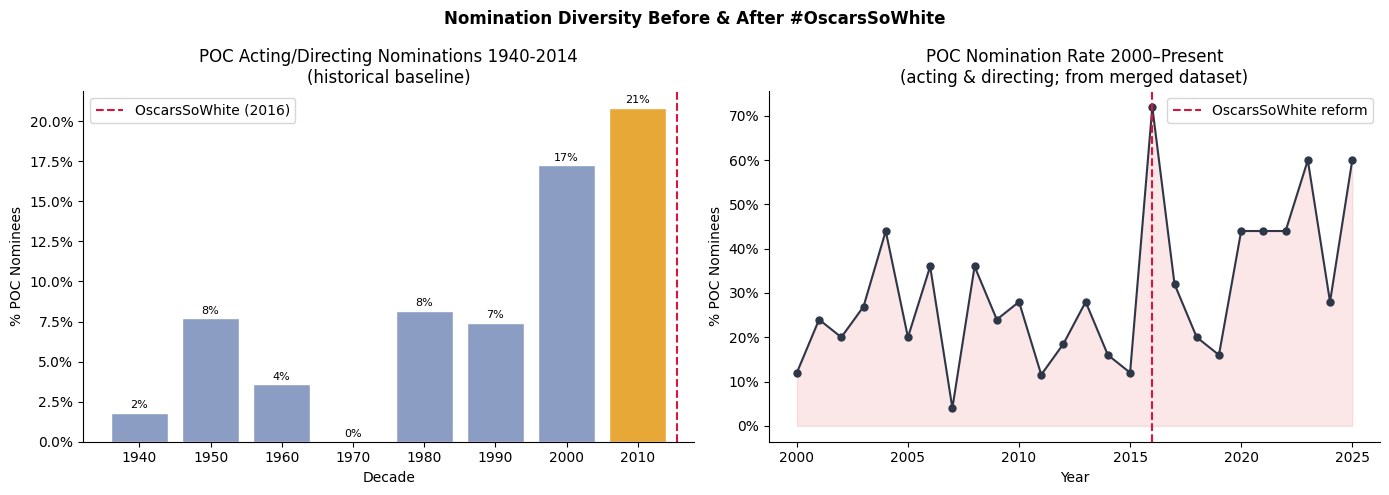

Saved to data_story_outputs/fig1_nomination_diversity.png


In [17]:
# -- 4d. Visualization: Nomination diversity trend ----------------------
diversity_by_year['Year'] = pd.to_numeric(diversity_by_year['Year'], errors='coerce')
# Also force poc_pct to float to fix fill_between error
diversity_by_year['poc_pct'] = diversity_by_year['poc_pct'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Nomination Diversity Before & After #OscarsSoWhite', fontweight='bold')

# Left: decade bars (historical baseline from religion_orientation.csv)
ax = axes[0]
colors = [C['post'] if d >= 2010 else C['pre'] for d in hist['decade']]
bars = ax.bar(hist['decade'], hist['poc_pct'] * 100, color=colors, width=8, edgecolor='white')
ax.axvline(2015.5, color='crimson', ls='--', lw=1.5, label='OscarsSoWhite (2016)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Decade'); ax.set_ylabel('% POC Nominees')
ax.set_title('POC Acting/Directing Nominations 1940-2014\n(historical baseline)')
ax.legend()
for bar, val in zip(bars, hist['poc_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.0%}', ha='center', fontsize=8)

# Right: year-by-year from merged data
ax = axes[1]
modern = diversity_by_year[diversity_by_year['Year'] >= 2000].sort_values('Year')
pct_vals = modern['poc_pct'].astype(float).values * 100  # fix fill_between dtype
year_vals = modern['Year'].astype(int).values

ax.plot(year_vals, pct_vals, color=C['dark'], lw=1.5, marker='o', markersize=5)
ax.fill_between(year_vals, pct_vals, alpha=0.12, color=C['poc'])
ax.axvline(2016, color='crimson', ls='--', lw=1.5, label='OscarsSoWhite reform')
rolling = modern['poc_pct'].astype(float).rolling(3, center=True).mean() * 100
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Year'); ax.set_ylabel('% POC Nominees')
ax.set_title('POC Nomination Rate 2000–Present\n(acting & directing; from merged dataset)')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig1_nomination_diversity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data_story_outputs/fig1_nomination_diversity.png')

## 5. Analysis Block B -- Box Office & Lead Race
*Did films with diverse leads perform differently at the box office? Did that relationship change after 2016?*

In [18]:
# -- 5a. Filter to Best Picture nominees --------------------------------
best_pic = merged[merged['CanonicalCategory'] == 'BEST PICTURE'].copy()

# Drop rows missing gross or lead_race (skip budget -- not in this dataset)
bp_analysis = best_pic.dropna(subset=[BO_GROSS, 'lead_race']).copy()
bp_analysis['is_poc_lead'] = bp_analysis['lead_race'].isin(
    ['Black', 'Asian', 'Hispanic', 'Multiracial', 'Middle Eastern']
)

print(f'Best Picture nominees          : {len(best_pic)}')
print(f'  with box office data         : {best_pic[BO_GROSS].notna().sum()}')
print(f'  with lead race               : {best_pic["lead_race"].notna().sum()}')
print(f'  analysis set (both present)  : {len(bp_analysis)}')
print(f'  POC lead   : {bp_analysis["is_poc_lead"].sum()}')
print(f'  White lead : {(~bp_analysis["is_poc_lead"]).sum()}')
print(f'  Pre-2016   : {(~bp_analysis["post_2016"]).sum()}')
print(f'  Post-2016  : {bp_analysis["post_2016"].sum()}')

Best Picture nominees          : 202
  with box office data         : 176
  with lead race               : 202
  analysis set (both present)  : 176
  POC lead   : 52
  White lead : 124
  Pre-2016   : 107
  Post-2016  : 69


In [19]:
# -- 5b. Descriptive stats: gross by lead race --------------------------
print('=== Median Domestic Gross ($M) by Lead Race ===')
print(bp_analysis.groupby('lead_race')[BO_GROSS]
      .agg(['median', 'mean', 'count']).round(1))

print('\n=== Pre/Post x Lead Race Comparison ===')
summary = (
    bp_analysis
    .groupby(['post_2016', 'is_poc_lead'])[BO_GROSS]
    .agg(['median', 'count'])
    .rename(columns={'median': 'median_gross_M', 'count': 'n'})
    .round(1)
)
summary.index = summary.index.map(
    lambda x: f"{'Post' if x[0] else 'Pre'}-2016 / {'POC' if x[1] else 'White'} lead"
)
print(summary)

# Note: ROI skipped -- no budget column in enhanced_box_office_data
# To add ROI later: join box_office.csv or a Kaggle budget dataset on title_key

=== Median Domestic Gross ($M) by Lead Race ===
           median   mean  count
lead_race                      
Asian        77.2   84.7     19
Black        80.2  128.5     28
Hispanic     11.3  138.0      5
Other        68.0   68.0      1
White        56.8  103.2    123

=== Pre/Post x Lead Race Comparison ===
                        median_gross_M   n
Pre-2016 / White lead             71.5  84
Pre-2016 / POC lead              107.1  23
Post-2016 / White lead            36.5  40
Post-2016 / POC lead              49.3  29


In [20]:
# -- 5c. Statistical tests: gross and ROI --------------------------------
poc_gross   = bp_analysis[bp_analysis['is_poc_lead']][BO_GROSS].dropna()
white_gross = bp_analysis[~bp_analysis['is_poc_lead']][BO_GROSS].dropna()

u1, p_gross = stats.mannwhitneyu(poc_gross, white_gross, alternative='two-sided')
print('=== Mann-Whitney U: Domestic Gross ===')
print(f'  POC lead   median: ${poc_gross.median():.1f}M  (n={len(poc_gross)})')
print(f'  White lead median: ${white_gross.median():.1f}M  (n={len(white_gross)})')
print(f'  U={u1:.0f}  p={p_gross:.3f}  ->  {"Significant" if p_gross < 0.05 else "Not significant"}')

poc_roi   = bp_analysis[bp_analysis['is_poc_lead']]['roi'].dropna()
white_roi = bp_analysis[~bp_analysis['is_poc_lead']]['roi'].dropna()
u2, p_roi = stats.mannwhitneyu(poc_roi, white_roi, alternative='two-sided')
print('\n=== Mann-Whitney U: ROI ===')
print(f'  POC lead   median ROI: {poc_roi.median():.2f}x  (n={len(poc_roi)})')
print(f'  White lead median ROI: {white_roi.median():.2f}x  (n={len(white_roi)})')
print(f'  U={u2:.0f}  p={p_roi:.3f}  ->  {"Significant" if p_roi < 0.05 else "Not significant"}')


=== Mann-Whitney U: Domestic Gross ===
  POC lead   median: $69.6M  (n=52)
  White lead median: $57.1M  (n=124)
  U=3309  p=0.784  ->  Not significant

=== Mann-Whitney U: ROI ===
  POC lead   median ROI: nanx  (n=0)
  White lead median ROI: nanx  (n=0)
  U=nan  p=nan  ->  Not significant


In [21]:
# -- 5d. OLS Regression: What predicts domestic gross? ------------------
import statsmodels.formula.api as smf

model_df = bp_analysis.copy()
model_df['log_gross'] = np.log1p(model_df[BO_GROSS])
model_df['poc']       = model_df['is_poc_lead'].astype(int)
model_df['post']      = model_df['post_2016'].astype(int)
model_df['won']       = model_df['Winner'].astype(int)

# Note: budget excluded (not in dataset) -- log_gross ~ poc + post + won + poc:post
# This means R-squared will be lower, but poc:post interaction is still meaningful
model = smf.ols(
    'log_gross ~ poc + post + won + poc:post',
    data=model_df.dropna(subset=['log_gross', 'poc', 'post', 'won'])
).fit()

print(model.summary())
print('\n*** Key coefficients of interest ***')
print(f'  poc      = {model.params["poc"]:.3f}  (POC lead baseline effect on log-gross)')
print(f'  post     = {model.params["post"]:.3f}  (post-2016 era effect)')
print(f'  poc:post = {model.params["poc:post"]:.3f}  (did POC films perform BETTER post-reform?)')
print(f'  won      = {model.params["won"]:.3f}  (winning Best Picture effect on gross)')
print(f'\n  R-squared = {model.rsquared:.3f}')
print('\n  Interpretation note: budget not controlled for (not in dataset).')
print('  A positive poc:post coefficient = POC-lead films earned more post-2016 relative to pre-2016.')

                            OLS Regression Results                            
Dep. Variable:              log_gross   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     2.853
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0253
Time:                        01:50:41   Log-Likelihood:                -283.24
No. Observations:                 176   AIC:                             576.5
Df Residuals:                     171   BIC:                             592.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.1524      0.138     30.105      0.0

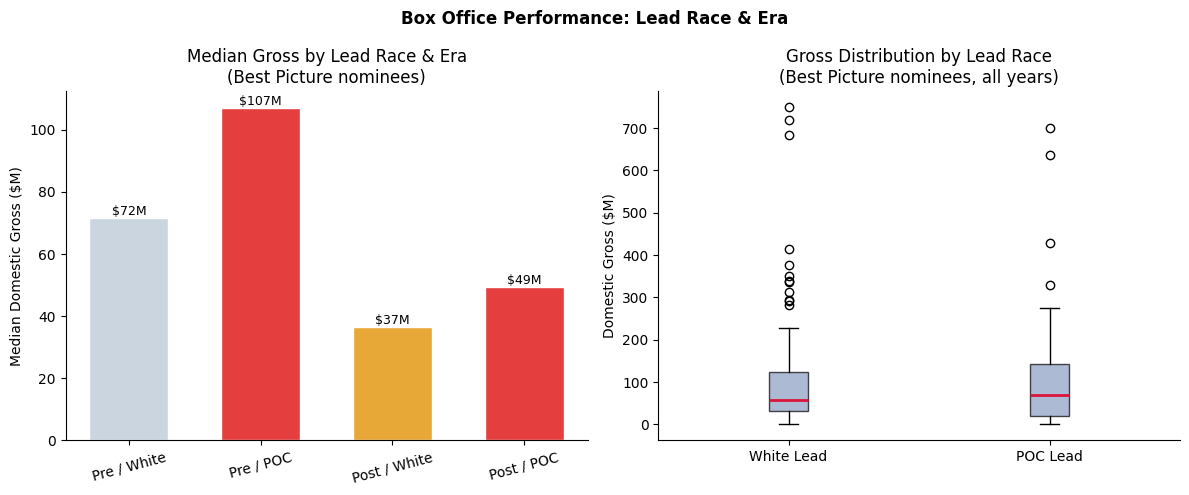

Saved to data_story_outputs/fig2_boxoffice_analysis.png


In [22]:
# -- 5e. Box office visualizations (2-panel, no budget) -----------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Box Office Performance: Lead Race & Era', fontweight='bold')

# 1. Grouped bar: median gross by era x lead
ax = axes[0]
groups  = ['Pre / White', 'Pre / POC', 'Post / White', 'Post / POC']
medians = [
    bp_analysis[(~bp_analysis['post_2016']) & (~bp_analysis['is_poc_lead'])][BO_GROSS].median(),
    bp_analysis[(~bp_analysis['post_2016']) &  bp_analysis['is_poc_lead']][BO_GROSS].median(),
    bp_analysis[ bp_analysis['post_2016']  & (~bp_analysis['is_poc_lead'])][BO_GROSS].median(),
    bp_analysis[ bp_analysis['post_2016']  &  bp_analysis['is_poc_lead']][BO_GROSS].median(),
]
bars = ax.bar(groups, medians,
              color=[C['white'], C['poc'], C['post'], C['poc']],
              edgecolor='white', width=0.6)
ax.set_ylabel('Median Domestic Gross ($M)')
ax.set_title('Median Gross by Lead Race & Era\n(Best Picture nominees)')
ax.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, medians):
    if not pd.isna(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'${val:.0f}M', ha='center', fontsize=9)

# 2. Gross distribution by lead race (box plot)
ax = axes[1]
poc_data   = bp_analysis[bp_analysis['is_poc_lead']][BO_GROSS].dropna()
white_data = bp_analysis[~bp_analysis['is_poc_lead']][BO_GROSS].dropna()
ax.boxplot([white_data, poc_data],
           labels=['White Lead', 'POC Lead'],
           patch_artist=True,
           boxprops=dict(facecolor=C['pre'], alpha=0.7),
           medianprops=dict(color='crimson', linewidth=2))
ax.set_ylabel('Domestic Gross ($M)')
ax.set_title('Gross Distribution by Lead Race\n(Best Picture nominees, all years)')

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig2_boxoffice_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data_story_outputs/fig2_boxoffice_analysis.png')

In [23]:
# -- 6. Extend to all major Oscar categories ----------------------------
major_cats = [
    'BEST PICTURE','BEST ACTOR','BEST ACTRESS',
    'BEST SUPPORTING ACTOR','BEST SUPPORTING ACTRESS','BEST DIRECTOR'
]
all_major = merged[merged['CanonicalCategory'].isin(major_cats)].copy()
all_major = all_major.dropna(subset=[BO_GROSS,'lead_race',BO_BUDGET])
all_major['is_poc_lead'] = all_major['lead_race'].isin(
    ['Black','Asian','Hispanic','Multiracial','Middle Eastern']
)

cat_race = (
    all_major
    .groupby(['CanonicalCategory','is_poc_lead'])[BO_GROSS]
    .median()
    .unstack()
    .rename(columns={False:'White lead', True:'POC lead'})
)
print('Median gross by category:')
print(cat_race.round(1))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cat_race))
w = 0.35
ax.bar(x - w/2, cat_race['White lead'].fillna(0), w, color=C['pre'],  label='White lead', edgecolor='white')
ax.bar(x + w/2, cat_race['POC lead'].fillna(0),   w, color=C['poc'],  label='POC lead',   edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([c.replace('BEST ','') for c in cat_race.index], rotation=15)
ax.set_ylabel('Median Domestic Gross ($M)')
ax.set_title('Median Gross by Oscar Category & Lead Race')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig3_gross_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data_story_outputs/fig3_gross_by_category.png')


KeyError: [None]

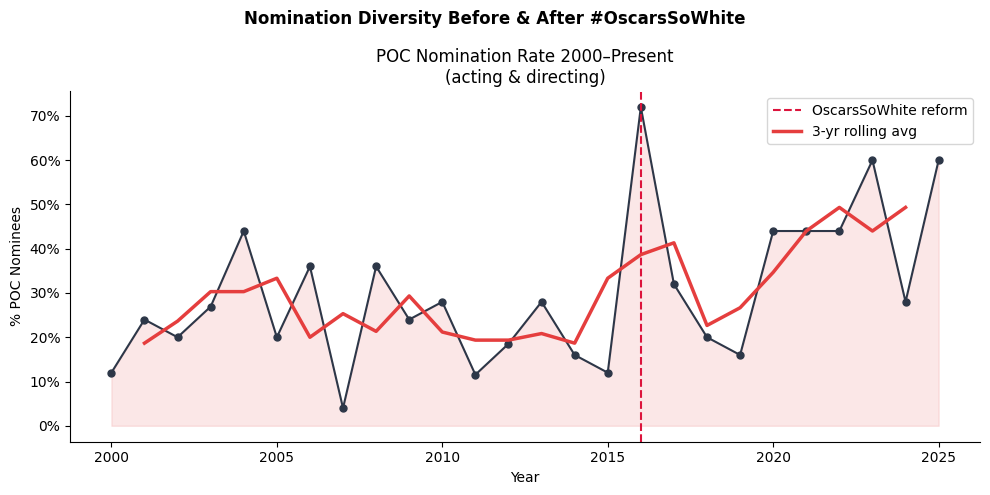

Saved to data_story_outputs/fig1_nomination_diversity.png


In [24]:
# -- 4d. Visualization: POC Nomination Rate 2000–Present ----------------
diversity_by_year['Year'] = pd.to_numeric(diversity_by_year['Year'], errors='coerce')
diversity_by_year['poc_pct'] = diversity_by_year['poc_pct'].astype(float)

modern = diversity_by_year[diversity_by_year['Year'] >= 2000].sort_values('Year')
pct_vals  = modern['poc_pct'].astype(float).values * 100
year_vals = modern['Year'].astype(int).values

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Nomination Diversity Before & After #OscarsSoWhite', fontweight='bold')

ax.plot(year_vals, pct_vals, color=C['dark'], lw=1.5, marker='o', markersize=5)
ax.fill_between(year_vals, pct_vals, alpha=0.12, color=C['poc'])
ax.axvline(2016, color='crimson', ls='--', lw=1.5, label='OscarsSoWhite reform')

rolling = modern['poc_pct'].astype(float).rolling(3, center=True).mean() * 100
ax.plot(year_vals, rolling, color=C['poc'], lw=2.5, label='3-yr rolling avg')

ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_xlabel('Year')
ax.set_ylabel('% POC Nominees')
ax.set_title('POC Nomination Rate 2000–Present\n(acting & directing)')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig1_nomination_diversity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data_story_outputs/fig1_nomination_diversity.png')

Median gross by category:
is_poc_lead                   White lead  POC lead
CanonicalCategory                                 
ACTOR IN A LEADING ROLE             40.3      57.5
ACTOR IN A SUPPORTING ROLE          50.8      58.2
ACTRESS IN A LEADING ROLE           30.0      39.4
ACTRESS IN A SUPPORTING ROLE        37.7      56.7
BEST PICTURE                        57.1      69.6
DIRECTING                           47.8      77.2


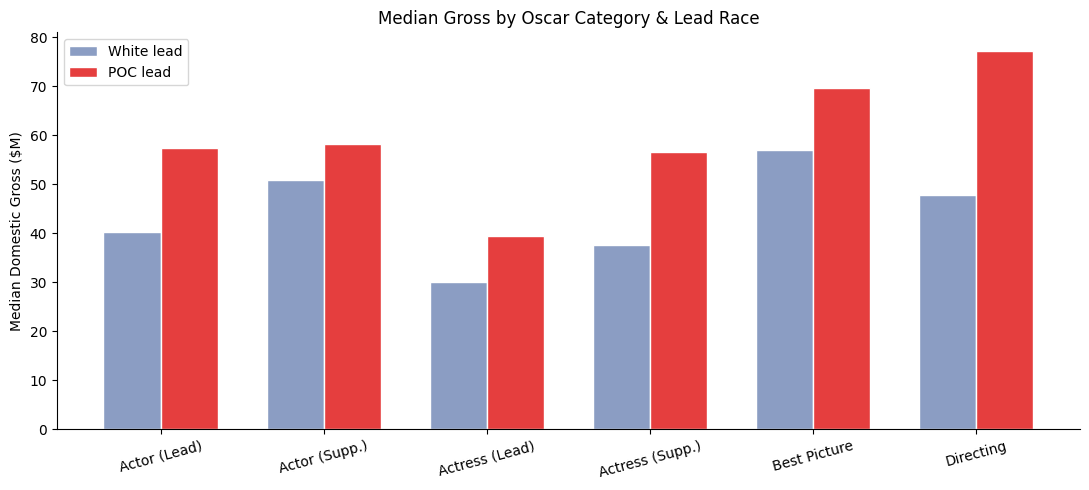

Saved to data_story_outputs/fig3_gross_by_category.png


In [25]:
# -- 6. Extend to all major Oscar categories ----------------------------
major_cats = [
    'BEST PICTURE',
    'ACTOR IN A LEADING ROLE',
    'ACTRESS IN A LEADING ROLE',
    'ACTOR IN A SUPPORTING ROLE',
    'ACTRESS IN A SUPPORTING ROLE',
    'DIRECTING',
]
all_major = merged[merged['CanonicalCategory'].isin(major_cats)].copy()
all_major = all_major.dropna(subset=[BO_GROSS, 'lead_race'])  # removed BO_BUDGET
all_major['is_poc_lead'] = all_major['lead_race'].isin(
    ['Black', 'Asian', 'Hispanic', 'Multiracial', 'Middle Eastern']
)

cat_race = (
    all_major
    .groupby(['CanonicalCategory', 'is_poc_lead'])[BO_GROSS]
    .median()
    .unstack()
    .rename(columns={False: 'White lead', True: 'POC lead'})
)
print('Median gross by category:')
print(cat_race.round(1))

# Clean up labels for display
label_map = {
    'BEST PICTURE'             : 'Best Picture',
    'ACTOR IN A LEADING ROLE'  : 'Actor (Lead)',
    'ACTRESS IN A LEADING ROLE': 'Actress (Lead)',
    'ACTOR IN A SUPPORTING ROLE'  : 'Actor (Supp.)',
    'ACTRESS IN A SUPPORTING ROLE': 'Actress (Supp.)',
    'DIRECTING'                : 'Directing',
}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(cat_race))
w = 0.35
ax.bar(x - w/2, cat_race['White lead'].fillna(0), w, color=C['pre'], label='White lead', edgecolor='white')
ax.bar(x + w/2, cat_race['POC lead'].fillna(0),   w, color=C['poc'], label='POC lead',   edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([label_map.get(c, c) for c in cat_race.index], rotation=15)
ax.set_ylabel('Median Domestic Gross ($M)')
ax.set_title('Median Gross by Oscar Category & Lead Race')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig3_gross_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data_story_outputs/fig3_gross_by_category.png')